# Data Analysis Python Project
### Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Import Data

In [12]:
df = pd.read_csv("C:\\Users\\Dell\\OneDrive\\Desktop\\STATISTICS\\Data analysis\\project\\Blinkit\\blinkit_data.csv")

In [13]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [14]:
df.shape

(8523, 12)

In [20]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')

In [15]:
df.dtypes

Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [21]:
round(df.describe(),1)

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.0,8523.0,7060.0,8523.0,8523.0
mean,2010.8,0.1,12.9,141.0,4.0
std,8.4,0.1,4.6,62.3,0.6
min,1998.0,0.0,4.6,31.3,1.0
25%,2000.0,0.0,8.8,93.8,4.0
50%,2012.0,0.1,12.6,143.0,4.0
75%,2017.0,0.1,16.8,185.6,4.2
max,2022.0,0.3,21.4,266.9,5.0


### Data Cleaning

In [23]:
df['Item Fat Content'].unique()

<StringArray>
['Regular', 'Low Fat', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

In [27]:
df['Item Fat Content']=df['Item Fat Content'].replace({'LF':'Low Fat',
                                'low fat': 'Low Fat',
                                'reg':'Regular'
                               })
df['Item Fat Content'].unique()

<StringArray>
['Regular', 'Low Fat']
Length: 2, dtype: str

### **Business Requirements**
### KPI's

In [31]:
# Total Sales
total_sales = df['Sales'].sum()
# Average Sales
avg_sales = df['Sales'].mean()
# No of items Sold
no_of_items_sold = df['Sales'].count()
# Average Ratings
avg_ratings = df['Rating'].mean()

# Print Results
print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${avg_sales:,.0f}")
print(f"No of Items Sold: {no_of_items_sold:,.0f}")
print(f"Average Ratings: {avg_ratings:,.1f}")


Total Sales: $1,201,681
Average Sales: $141
No of Items Sold: 8,523
Average Ratings: 4.0


### **Charts**
### Total Sales by Fat Contents

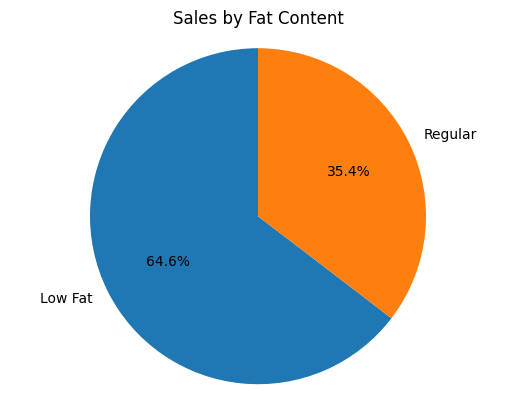

In [34]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat, labels=sales_by_fat.index,
        autopct='%.1f%%',
        startangle = 90)
plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

### Total Sales Item Type

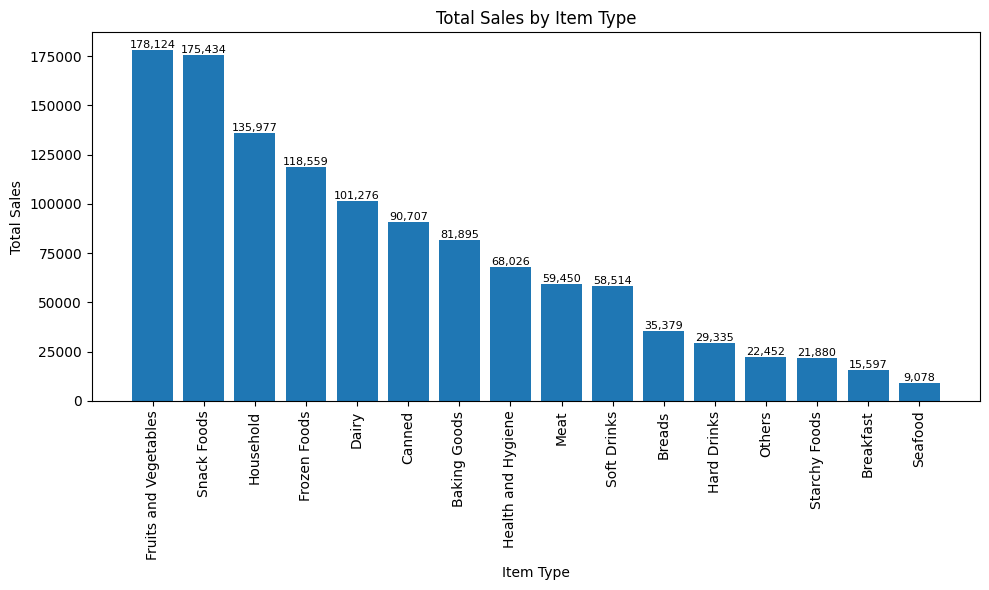

In [40]:
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
bars=plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation=90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, # Calculates the center of the bar
             bar.get_height(),
         f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Fat Content by Outlet for Total Sales

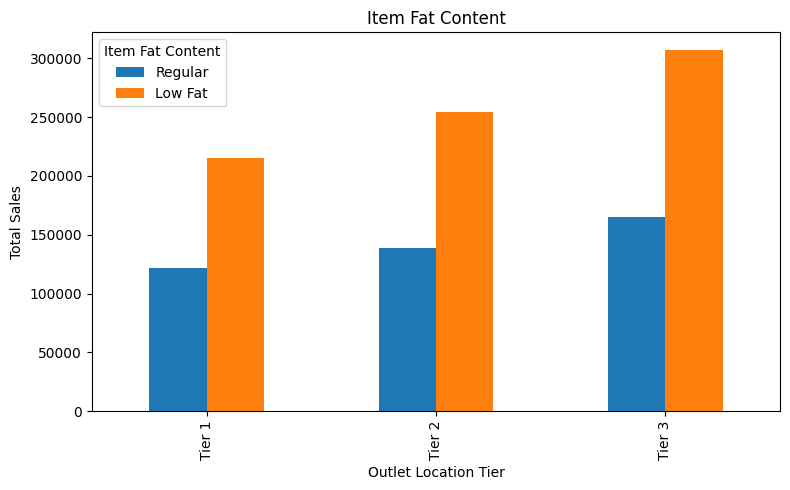

In [46]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]
ax= grouped.plot(kind='bar', figsize=(8,5), title='Outlet Tier By Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.title('Item Fat Content')
plt.tight_layout()
plt.show()

### Total Sales by Outlet Establishment

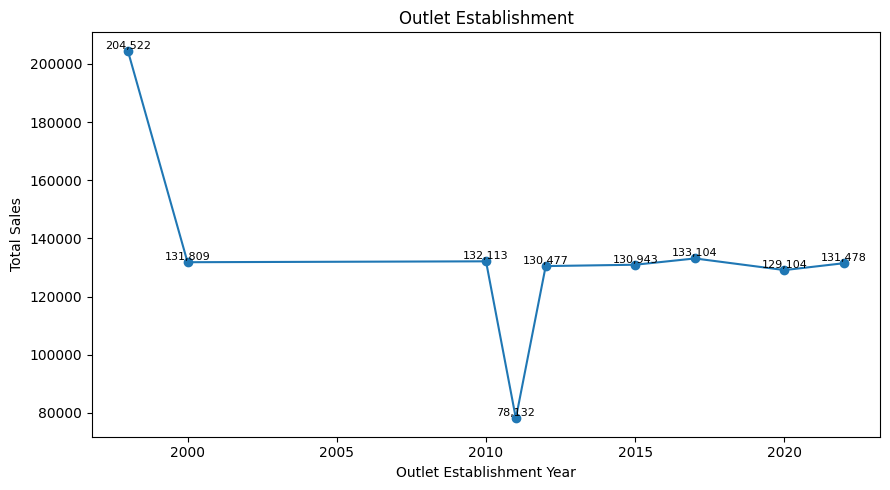

In [47]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x,y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Sales by Outlet Size

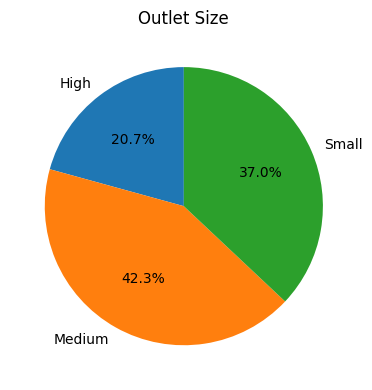

In [48]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_size, labels=sales_by_size.index, autopct='%1.1f%%', startangle=90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

### Sales by Outlet Location

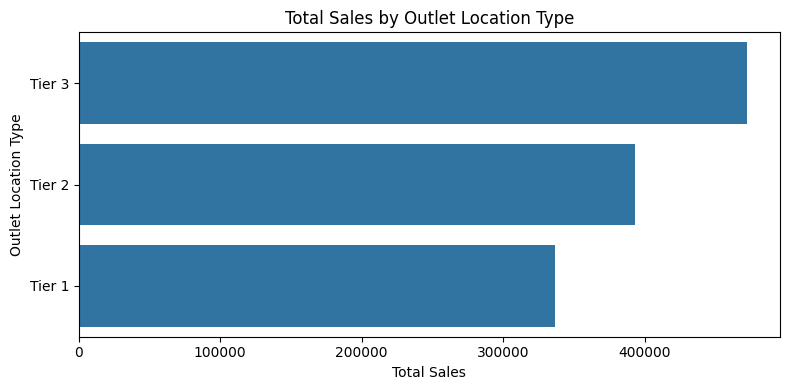

In [53]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Sales', ascending=False)

plt.figure(figsize=(8,4))
ax = sns.barplot(x='Sales', y='Outlet Location Type', data=sales_by_location)

plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout()
plt.show()

In [55]:
import os

print(os.getcwd())


C:\Users\Dell
